In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using parquet format
# ../ means go up one folder from notebooks/ into the project root, then into data/
df = pd.read_parquet('../data/DDoS-Friday-no-metadata.parquet')

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully
Shape: (221264, 78)
Rows: 221,264
Columns: 78


In [2]:
# See what types of traffic exist
# Label is what you are predicting — BENIGN or DDoS
print("Traffic types in dataset:")
print(df['Label'].value_counts())
print()
print(f"Total rows: {len(df):,}")

Traffic types in dataset:
Label
DDoS      128014
Benign     93250
Name: count, dtype: int64

Total rows: 221,264


In [3]:
# Check for missing values
missing = df.isnull().sum().sum()
print(f"Total missing values: {missing}")

# Check for infinite values
# These happen in network data when something gets divided by zero
numeric_cols = df.select_dtypes(include=[np.number])
infinite = np.isinf(numeric_cols).sum().sum()
print(f"Total infinite values: {infinite}")

# Check data types
print(f"\nColumn data types:")
print(df.dtypes.value_counts())

Total missing values: 0
Total infinite values: 0

Column data types:
float32     22
int8        21
int32       21
int16       11
float64      2
category     1
Name: count, dtype: int64


In [4]:
# See what the actual data looks like
# Shows first 3 rows, first 10 columns only for readability
print("Sample data (first 3 rows, first 10 columns):")
df.iloc[:3, :10]

Sample data (first 3 rows, first 10 columns):


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std
0,6,3,2,0,12,0,6,6,6.0,0.0
1,6,109,1,1,6,6,6,6,6.0,0.0
2,6,52,1,1,6,6,6,6,6.0,0.0


In [5]:
# Split into two groups
benign = df[df['Label'] == 'BENIGN']
attack = df[df['Label'] == 'DDoS']

# Compare averages on key features
# This shows WHY machine learning can detect DDoS
# The numbers between normal and attack traffic will be dramatically different
print("Feature comparison — Normal traffic vs DDoS attack traffic:")
print()

features_to_compare = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s'
]

for feature in features_to_compare:
    normal_avg = benign[feature].mean()
    attack_avg = attack[feature].mean()
    print(f"{feature}:")
    print(f"  Normal avg: {normal_avg:,.2f}")
    print(f"  DDoS avg:   {attack_avg:,.2f}")
    print()

Feature comparison — Normal traffic vs DDoS attack traffic:

Flow Duration:
  Normal avg: nan
  DDoS avg:   16,957,157.95

Total Fwd Packets:
  Normal avg: nan
  DDoS avg:   4.47

Total Backward Packets:
  Normal avg: nan
  DDoS avg:   3.26

Flow Bytes/s:
  Normal avg: nan
  DDoS avg:   60,509.89

Flow Packets/s:
  Normal avg: nan
  DDoS avg:   155.39



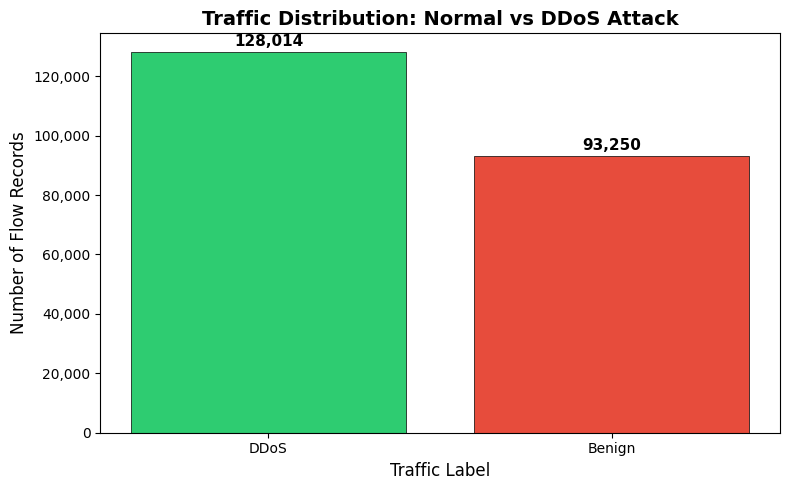

Chart saved to outputs/01-class-distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Green for benign, red for attack

bars = ax.bar(counts.index, counts.values, color=colors,
              edgecolor='black', linewidth=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f'{count:,}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Traffic Distribution: Normal vs DDoS Attack',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Flow Records', fontsize=12)
ax.set_xlabel('Traffic Label', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../outputs/01-class-distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/01-class-distribution.png")

In [7]:
import json

summary = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'benign_count': int(df['Label'].value_counts()['BENIGN']),
    'ddos_count': int(df['Label'].value_counts()['DDoS']),
    'missing_values': int(df.isnull().sum().sum()),
    'infinite_values': int(
        np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    )
}

with open('../outputs/day1-summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Day 1 Summary saved:")
for key, value in summary.items():
    print(f"  {key}: {value:,}" if isinstance(value, int)
          else f"  {key}: {value}")

KeyError: 'BENIGN'

In [8]:
# Check the actual label names in this dataset
print(df['Label'].value_counts())
print()
print("Unique labels:", df['Label'].unique())

Label
DDoS      128014
Benign     93250
Name: count, dtype: int64

Unique labels: ['Benign', 'DDoS']
Categories (2, str): ['Benign', 'DDoS']


In [9]:
# Split into two groups
benign = df[df['Label'] == 'Benign']
attack = df[df['Label'] == 'DDoS']

print("Feature comparison — Normal traffic vs DDoS attack traffic:")
print()

features_to_compare = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s'
]

for feature in features_to_compare:
    normal_avg = benign[feature].mean()
    attack_avg = attack[feature].mean()
    print(f"{feature}:")
    print(f"  Normal avg: {normal_avg:,.2f}")
    print(f"  DDoS avg:   {attack_avg:,.2f}")
    print()

Feature comparison — Normal traffic vs DDoS attack traffic:

Flow Duration:
  Normal avg: 16,039,624.54
  DDoS avg:   16,957,157.95

Total Fwd Packets:
  Normal avg: 5.56
  DDoS avg:   4.47

Total Backward Packets:
  Normal avg: 6.56
  DDoS avg:   3.26

Flow Bytes/s:
  Normal avg: 565,248.37
  DDoS avg:   60,509.89

Flow Packets/s:
  Normal avg: 19,023.01
  DDoS avg:   155.39



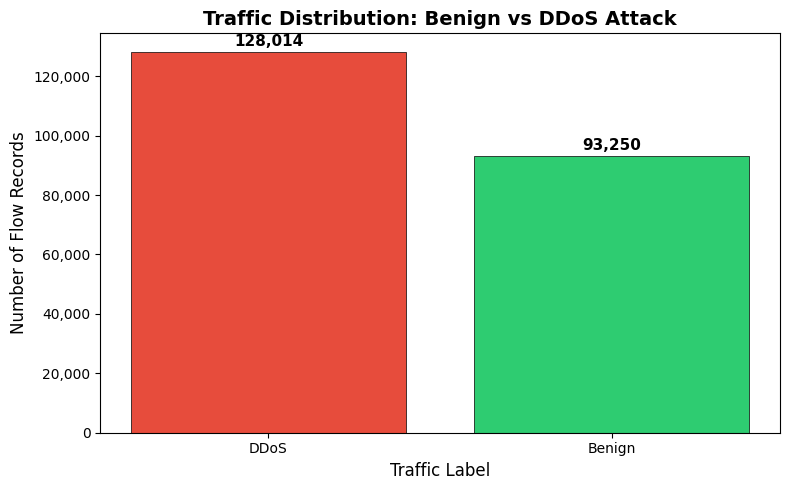

Chart saved to outputs/01-class-distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = df['Label'].value_counts()
colors = ['#e74c3c', '#2ecc71']  # DDoS is first in this dataset

bars = ax.bar(counts.index.astype(str), counts.values, color=colors,
              edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f'{count:,}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Traffic Distribution: Benign vs DDoS Attack',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Flow Records', fontsize=12)
ax.set_xlabel('Traffic Label', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../outputs/01-class-distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/01-class-distribution.png")

In [11]:
import json

summary = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'benign_count': int(df['Label'].value_counts()['Benign']),
    'ddos_count': int(df['Label'].value_counts()['DDoS']),
    'missing_values': int(df.isnull().sum().sum()),
    'infinite_values': int(
        np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    )
}

with open('../outputs/day1-summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Day 1 Summary saved:")
for key, value in summary.items():
    print(f"  {key}: {value:,}" if isinstance(value, int)
          else f"  {key}: {value}")

Day 1 Summary saved:
  total_rows: 221,264
  total_columns: 78
  benign_count: 93,250
  ddos_count: 128,014
  missing_values: 0
  infinite_values: 0
